#  XGBoost  Training(2016—2019) - Respira SP

Este notebook dá continuidade à preparação dos dados, utilizando os datasets supervisionados da base **2016–2019** para treinar, regularizar e avaliar modelos XGBoost na previsão de `PM2.5` 24 horas à frente.

Foram comparadas três estratégias de pré-processamento para tratamento de gaps, além de diferentes configurações do XGBoost: modelo inicial, modelo regularizado, modelo com novas features temporais e modelo regularizado com novas features temporais.

## O que foi feito

* Carregamento dos datasets supervisionados referentes às três estratégias de pré-processamento;
* Adição das features meteorológicas ausentes a partir da base Open-Meteo:

  * `precipitation`
  * `wind_speed_10m`
* Remoção da coluna `MP2.5` original para evitar seu uso direto como feature no modelo;
* Definição das features utilizadas no treinamento e do target `target_24h`;
* Realização do split temporal dos dados:

  * Treino: dados anteriores a 2018;
  * Validação: dados de 2018;
  * Teste: dados de 2019;
* Treinamento de um baseline simples baseado em `PM2.5_lag_24h`;
* Treinamento inicial do modelo XGBoost para cada estratégia de pré-processamento;
* Avaliação dos modelos com `MAE`, `RMSE` e `R²`;
* Comparação entre baseline e XGBoost no conjunto de validação;
* Avaliação final dos modelos no conjunto de teste;
* Análise de `feature importance`;
* Análise de desempenho por split;
* Construção de learning curves para investigar possíveis sinais de overfitting, underfitting ou data leakage;
* Realização de `GridSearchCV` com `TimeSeriesSplit` para buscar configurações mais regularizadas;
* Treinamento de modelos XGBoost regularizados usando os melhores hiperparâmetros encontrados;
* Criação de novas features temporais:

  * `hora_sin` / `hora_cos`;
  * `mes_sin` / `mes_cos`;
  * `dia_semana_sin` / `dia_semana_cos`;
  * `PM2.5_diff_1h`;
  * `PM2.5_diff_3h`;
  * `PM2.5_diff_6h`;
  * `PM2.5_diff_24h`;
* Treinamento de XGBoost inicial com as novas features temporais;
* Treinamento de XGBoost regularizado com as novas features temporais;
* Novo GridSearch com as features temporais para verificar se os hiperparâmetros poderiam melhorar ainda mais o desempenho;
* Comparação final entre:

  * Modelos iniciais;
  * Modelos regularizados;
  * Modelos iniciais com features temporais;
  * Modelos regularizados com features temporais;
  * Modelos com GridSearch usando features temporais.

## Melhor configuração encontrada

A melhor configuração geral foi:

**Base:** 2016–2019
**Estratégia:** Estratégia 3 — interpolação de gaps pequenos + imputação por média sazonal
**Modelo:** XGBoost regularizado + features temporais

### Resultado em validação

* `MAE`: 7.519
* `RMSE`: 10.607
* `R²`: 0.300

### Resultado em teste

* `MAE`: 7.771
* `RMSE`: 10.787
* `R²`: 0.295

Embora a Estratégia 1 regularizada com features temporais tenha apresentado RMSE ligeiramente menor no teste, a Estratégia 3 regularizada com features temporais foi considerada a melhor configuração geral por apresentar melhor desempenho na validação, melhor `MAE` e melhor `R²` no teste, além de utilizar a estratégia mais completa de tratamento de gaps.

## Observação

Na base 2016–2019, a regularização do XGBoost reduziu sinais de overfitting observados nas learning curves iniciais e trouxe melhora consistente nas métricas de teste. A adição de novas features temporais também contribuiu para melhorar o desempenho, especialmente quando combinada com o modelo regularizado.

O novo GridSearch realizado com as features temporais não superou a configuração regularizada anterior com features temporais. Portanto, a melhor configuração final permaneceu sendo a Estratégia 3 com XGBoost regularizado e features temporais.

A base utilizada corresponde ao período histórico de **2016 a 2019** e mantém as seguintes features meteorológicas:

* `temperature_2m`
* `relative_humidity_2m`
* `precipitation`
* `wind_speed_10m`


In [7]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 23.7 MB/s  0:00:00

[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import early_stopping, log_evaluation

In [4]:
# Importando as bases de dados 2016-2019 Reaproveitar os dfs do XGBoost para o LightGBM
# Estrategia 1 sem imterpolação temporal / sazonal
df_estrategia01 = pd.read_csv("../data/processed_data/xgb_estrategia01_2016_2019_target_24h.csv")
df_estrategia01.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,mes,hora,dia_semana,target_24h,PM2.5_lag_1h,PM2.5_lag_3h,PM2.5_lag_6h,PM2.5_lag_12h,PM2.5_lag_24h,PM2.5_rolling_mean_3h,PM2.5_rolling_mean_6h,PM2.5_rolling_mean_12h,PM2.5_rolling_mean_24h,PM2.5_rolling_std_24h
0,2016-03-02 00:00:00+00:00,6.0,17.951000,97.205025,0.0,10.233123,3,0,2,22.0,11.0,16.0,16.0,18.0,3.0,14.666667,15.166667,15.500000,13.375000,4.470313
1,2016-03-02 01:00:00+00:00,14.0,17.901001,97.819305,0.6,8.669949,3,1,2,27.0,6.0,17.0,15.0,17.0,1.0,11.333333,13.500000,14.500000,13.500000,4.201449
2,2016-03-02 02:00:00+00:00,9.0,17.801000,98.126830,0.0,10.086427,3,2,2,28.0,14.0,11.0,16.0,20.0,18.0,10.333333,13.333333,14.250000,14.041667,3.250139
3,2016-03-02 03:00:00+00:00,7.0,17.801000,97.509340,0.0,9.585739,3,3,2,22.0,9.0,6.0,16.0,15.0,17.0,9.666667,12.166667,13.333333,13.666667,3.292504
4,2016-03-02 04:00:00+00:00,18.0,17.651001,97.506485,0.0,8.161764,3,4,2,20.0,7.0,14.0,17.0,12.0,10.0,10.000000,10.666667,12.666667,13.250000,3.479755


In [5]:
# Estrategia 2  imterpolação temporal
df_estrategia02 = pd.read_csv("../data/processed_data/xgb_estrategia02_2016_2019_target_24h.csv")
df_estrategia02.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,mes,hora,dia_semana,target_24h,PM2.5_lag_1h,PM2.5_lag_3h,PM2.5_lag_6h,PM2.5_lag_12h,PM2.5_lag_24h,PM2.5_rolling_mean_3h,PM2.5_rolling_mean_6h,PM2.5_rolling_mean_12h,PM2.5_rolling_mean_24h,PM2.5_rolling_std_24h
0,2016-03-02 00:00:00+00:00,6.0,17.951000,97.205025,0.0,10.233123,3,0,2,22.0,11.0,16.0,16.0,18.0,3.0,14.666667,15.166667,15.500000,13.375000,4.470313
1,2016-03-02 01:00:00+00:00,14.0,17.901001,97.819305,0.6,8.669949,3,1,2,27.0,6.0,17.0,15.0,17.0,1.0,11.333333,13.500000,14.500000,13.500000,4.201449
2,2016-03-02 02:00:00+00:00,9.0,17.801000,98.126830,0.0,10.086427,3,2,2,28.0,14.0,11.0,16.0,20.0,18.0,10.333333,13.333333,14.250000,14.041667,3.250139
3,2016-03-02 03:00:00+00:00,7.0,17.801000,97.509340,0.0,9.585739,3,3,2,22.0,9.0,6.0,16.0,15.0,17.0,9.666667,12.166667,13.333333,13.666667,3.292504
4,2016-03-02 04:00:00+00:00,18.0,17.651001,97.506485,0.0,8.161764,3,4,2,20.0,7.0,14.0,17.0,12.0,10.0,10.000000,10.666667,12.666667,13.250000,3.479755


In [6]:
# Estrategia 3  imterpolação temporal
df_estrategia03 = pd.read_csv("../data/processed_data/xgb_estrategia03_2016_2019_target_24h.csv")
df_estrategia03.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,mes,hora,dia_semana,MP2.5_imputado_media,precipitation,wind_speed_10m,...,PM2.5_lag_1h,PM2.5_lag_3h,PM2.5_lag_6h,PM2.5_lag_12h,PM2.5_lag_24h,PM2.5_rolling_mean_3h,PM2.5_rolling_mean_6h,PM2.5_rolling_mean_12h,PM2.5_rolling_mean_24h,PM2.5_rolling_std_24h
0,2016-03-02 00:00:00+00:00,6.0,17.951000,97.205025,3,0,2,0,0.0,10.233123,...,11.0,16.0,16.0,18.0,3.0,14.666667,15.166667,15.500000,13.375000,4.470313
1,2016-03-02 01:00:00+00:00,14.0,17.901001,97.819305,3,1,2,0,0.6,8.669949,...,6.0,17.0,15.0,17.0,1.0,11.333333,13.500000,14.500000,13.500000,4.201449
2,2016-03-02 02:00:00+00:00,9.0,17.801000,98.126830,3,2,2,0,0.0,10.086427,...,14.0,11.0,16.0,20.0,18.0,10.333333,13.333333,14.250000,14.041667,3.250139
3,2016-03-02 03:00:00+00:00,7.0,17.801000,97.509340,3,3,2,0,0.0,9.585739,...,9.0,6.0,16.0,15.0,17.0,9.666667,12.166667,13.333333,13.666667,3.292504
4,2016-03-02 04:00:00+00:00,18.0,17.651001,97.506485,3,4,2,0,0.0,8.161764,...,7.0,14.0,17.0,12.0,10.0,10.000000,10.666667,12.666667,13.250000,3.479755


## Criar a feature "is_weekend" para o LightGBM

In [7]:
for df in [df_estrategia01, df_estrategia02, df_estrategia03]:
    df["is_weekend"] = (df["dia_semana"] >= 5).astype(int)

In [8]:
df_estrategia01[["time", "dia_semana", "is_weekend"]].head(10)

,time,dia_semana,is_weekend
0,2016-03-02 00:00:00+00:00,2,0
1,2016-03-02 01:00:00+00:00,2,0
2,2016-03-02 02:00:00+00:00,2,0
3,2016-03-02 03:00:00+00:00,2,0
4,2016-03-02 04:00:00+00:00,2,0
5,2016-03-02 05:00:00+00:00,2,0
6,2016-03-02 06:00:00+00:00,2,0
7,2016-03-02 07:00:00+00:00,2,0
8,2016-03-02 08:00:00+00:00,2,0
9,2016-03-02 09:00:00+00:00,2,0


In [20]:
print(df_estrategia01["is_weekend"].value_counts())
print(df_estrategia02["is_weekend"].value_counts())
print(df_estrategia03["is_weekend"].value_counts())

is_weekend
0    19176
1     7841
Name: count, dtype: int64
is_weekend
0    19972
1     8045
Name: count, dtype: int64
is_weekend
0    21672
1     8643
Name: count, dtype: int64


In [22]:
print(df_estrategia01["is_weekend"].isna().sum())
print(df_estrategia02["is_weekend"].isna().sum())
print(df_estrategia02["is_weekend"].isna().sum())

0
0
0


In [7]:
features = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m",
    "mes",
    "hora",
    "dia_semana",
    "is_weekend",
    "PM2.5_lag_1h",
    "PM2.5_lag_3h",
    "PM2.5_lag_6h",
    "PM2.5_lag_12h",
    "PM2.5_lag_24h",
    "PM2.5_rolling_mean_3h",
    "PM2.5_rolling_mean_6h",
    "PM2.5_rolling_mean_12h",
    "PM2.5_rolling_mean_24h",
    "PM2.5_rolling_std_24h"
]

target = "target_24h"

In [10]:
#Salvando os dfs
df_estrategia01.to_csv(
    "../data/processed_data/lightGBM_estrategia01_2016_2019_target_24h.csv",
    index=False
)

df_estrategia02.to_csv(
    "../data/processed_data/lightGBM_estrategia02_2016_2019_target_24h.csv",
    index=False
)

df_estrategia03.to_csv(
    "../data/processed_data/lightGBM_estrategia03_2016_2019_target_24h.csv",
    index=False
)

## Split temporal

In [4]:
df_estrategia01 = pd.read_csv("../data/processed_data/lightGBM_estrategia01_2016_2019_target_24h.csv")
df_estrategia02 = pd.read_csv("../data/processed_data/lightGBM_estrategia02_2016_2019_target_24h.csv")
df_estrategia03 = pd.read_csv("../data/processed_data/lightGBM_estrategia01_2016_2019_target_24h.csv")

In [5]:
#função para split temporal
def split_temporal(df, features, target):
    df = df.sort_values("time").copy()

    train = df[df["time"] < "2018-01-01"].copy()
    val = df[(df["time"] >= "2018-01-01") & (df["time"] < "2019-01-01")].copy()
    test = df[df["time"] >= "2019-01-01"].copy()

    X_train = train[features]
    y_train = train[target]

    X_val = val[features]
    y_val = val[target]

    X_test = test[features]
    y_test = test[target]

    return X_train, X_val, X_test, y_train, y_val, y_test

In [8]:
#split na 1 estrategia
X_train_01, X_val_01, X_test_01, y_train_01, y_val_01, y_test_01 = split_temporal(
    df_estrategia01, features, target
)

#split na 2 estrategia
X_train_02, X_val_02, X_test_02, y_train_02, y_val_02, y_test_02 = split_temporal(
    df_estrategia02, features, target
)

#split na 3 estrategia
X_train_03, X_val_03, X_test_03, y_train_03, y_val_03, y_test_03 = split_temporal(
    df_estrategia03, features, target
)

In [73]:
print(X_train_01.shape, X_val_01.shape, X_test_01.shape)
print(X_train_02.shape, X_val_02.shape, X_test_02.shape)
print(X_train_03.shape, X_val_03.shape, X_test_03.shape)

(14532, 18) (7475, 18) (5010, 18)
(15192, 18) (7604, 18) (5221, 18)
(16080, 18) (8760, 18) (5475, 18)


In [74]:
print(X_train_01.isna().sum().sum(), X_val_01.isna().sum().sum(), X_test_01.isna().sum().sum())
print(X_train_02.isna().sum().sum(), X_val_02.isna().sum().sum(), X_test_02.isna().sum().sum())
print(X_train_03.isna().sum().sum(), X_val_03.isna().sum().sum(), X_test_03.isna().sum().sum())

0 0 0
0 0 0
0 0 0


In [75]:
print(y_train_01.isna().sum(), y_val_01.isna().sum(), y_test_01.isna().sum())
print(y_train_02.isna().sum(), y_val_02.isna().sum(), y_test_02.isna().sum())
print(y_train_03.isna().sum(), y_val_03.isna().sum(), y_test_03.isna().sum())

0 0 0
0 0 0
0 0 0


## Avaliação Baseline na validação

In [10]:
def avaliar_modelo(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

In [77]:
y_pred_baseline_01 = X_val_01["PM2.5_lag_24h"]
y_pred_baseline_02 = X_val_02["PM2.5_lag_24h"]
y_pred_baseline_03 = X_val_03["PM2.5_lag_24h"]

baseline_01 = avaliar_modelo(y_val_01, y_pred_baseline_01)
baseline_02 = avaliar_modelo(y_val_02, y_pred_baseline_02)
baseline_03 = avaliar_modelo(y_val_03, y_pred_baseline_03)

baseline_01, baseline_02, baseline_03

({'MAE': 11.016989966555183,
  'RMSE': 15.610750090711491,
  'R2': -0.39173078414061124},
 {'MAE': 11.028581448360514,
  'RMSE': 15.646441218400593,
  'R2': -0.411274593292444},
 {'MAE': 10.533703685044673,
  'RMSE': 15.031295586061354,
  'R2': -0.4053794239429711})

## Treinando Modelo LightGBM

In [15]:
def train_lgbm(X_train, y_train, X_val, y_val):
    model = LGBMRegressor(
        objective="regression",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=0,
        verbosity=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    resultados = {
        "MAE": mean_absolute_error(y_val, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_val, y_pred)),
        "R2": r2_score(y_val, y_pred)
    }

    return model, y_pred, resultados

In [16]:
#Fazendo na estrategia 1
modelo_01, y_pred_val_01, resultados_gbm_01 = train_lgbm(
    X_train_01, y_train_01, X_val_01, y_val_01
)

#Fazendo na estrategia 2
modelo_02, y_pred_val_02, resultados_gbm_02 = train_lgbm(
    X_train_02, y_train_02, X_val_02, y_val_02
)

#Fazendo na estrategia 3
modelo_03, y_pred_val_03, resultados_gbm_03 = train_lgbm(
    X_train_03, y_train_03, X_val_03, y_val_03
)

## Comparando baseline vs LightGBM

In [80]:
resultados_comp = pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "Baseline lag_24h", **baseline_01},
    {"estrategia": "Estratégia 1", "modelo": "LightGBM", **resultados_gbm_01},

    {"estrategia": "Estratégia 2", "modelo": "Baseline lag_24h", **baseline_02},
    {"estrategia": "Estratégia 2", "modelo": "LightGBM", **resultados_gbm_02},

    {"estrategia": "Estratégia 3", "modelo": "Baseline lag_24h", **baseline_03},
    {"estrategia": "Estratégia 3", "modelo": "LightGBM", **resultados_gbm_03},
])

resultados_comp

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,Baseline lag_24h,11.016990,15.610750,-0.391731
1,Estratégia 1,LightGBM,8.149680,11.426112,0.254402
2,Estratégia 2,Baseline lag_24h,11.028581,15.646441,-0.411275
3,Estratégia 2,LightGBM,8.067848,11.331423,0.259800
4,Estratégia 3,Baseline lag_24h,10.533704,15.031296,-0.405379
5,Estratégia 3,LightGBM,7.702218,10.945866,0.254752


### o LightGBM superou o baseline nas três estratégias de pré-processamento.

### fazer o test no modelo

In [23]:
y_pred_test_01 = modelo_01.predict(X_test_01)
y_pred_test_02 = modelo_02.predict(X_test_02)
y_pred_test_03 = modelo_03.predict(X_test_03)

resultados_test_01 = avaliar_modelo(y_test_01, y_pred_test_01)
resultados_test_02 = avaliar_modelo(y_test_02, y_pred_test_02)
resultados_test_03 = avaliar_modelo(y_test_03, y_pred_test_03)

pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "LightGBM", "split": "Teste", **resultados_test_01},
    {"estrategia": "Estratégia 2", "modelo": "LightGBM", "split": "Teste", **resultados_test_02},
    {"estrategia": "Estratégia 3", "modelo": "LightGBM", "split": "Teste", **resultados_test_03},
    ])

,estrategia,modelo,split,MAE,RMSE,R2
0,Estratégia 1,LightGBM,Teste,7.915592,11.051484,0.247779
1,Estratégia 2,LightGBM,Teste,7.914312,11.085361,0.262430
2,Estratégia 3,LightGBM,Teste,7.915592,11.051484,0.247779


## Ver o feature importance do modelo

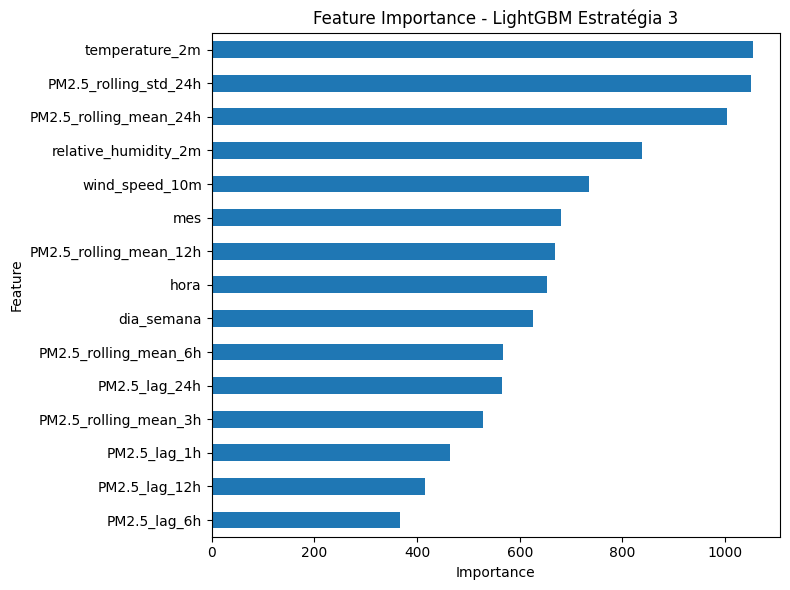

In [82]:
feature_importance_03 = pd.DataFrame({
    "feature": X_train_03.columns,
    "importance": modelo_03.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_03.head(15).plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8, 6),
    legend=False
)

plt.gca().invert_yaxis()
plt.title("Feature Importance - LightGBM Estratégia 3")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [83]:
feature_importance_03[feature_importance_03["feature"] == "is_weekend"]

,feature,importance
7,is_weekend,25


In [90]:
def plot_learning_curves_lgbm_estrateg(
    estrategias,
    n_splits=5,
    train_sizes=np.linspace(0.1, 1.0, 5)
):
    
    fig, axes = plt.subplots(
        nrows=len(estrategias),
        ncols=1,
        figsize=(10, 5 * len(estrategias)),
        sharex=False
    )

    if len(estrategias) == 1:
        axes = [axes]

    for ax, (nome, (X_train, y_train)) in zip(axes, estrategias.items()):

        pipeline_lgbm = make_pipeline(
            LGBMRegressor(
                objective="regression",
                n_estimators=500,
                learning_rate=0.05,
                max_depth=5,
                num_leaves=31,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1,
                verbose=-1,
                verbosity=-1
            )
        )

        tscv = TimeSeriesSplit(n_splits=n_splits)

        train_sizes_abs, train_scores, val_scores = learning_curve(
            estimator=pipeline_lgbm,
            X=X_train,
            y=y_train,
            train_sizes=train_sizes,
            cv=tscv,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1
        )

        train_rmse = -train_scores
        val_rmse = -val_scores

        train_rmse_mean = train_rmse.mean(axis=1)
        train_rmse_std = train_rmse.std(axis=1)

        val_rmse_mean = val_rmse.mean(axis=1)
        val_rmse_std = val_rmse.std(axis=1)

        ax.plot(
            train_sizes_abs,
            train_rmse_mean,
            marker="o",
            label="Train RMSE"
        )

        ax.plot(
            train_sizes_abs,
            val_rmse_mean,
            marker="o",
            label="Validation RMSE"
        )

        ax.fill_between(
            train_sizes_abs,
            train_rmse_mean - train_rmse_std,
            train_rmse_mean + train_rmse_std,
            alpha=0.2
        )

        ax.fill_between(
            train_sizes_abs,
            val_rmse_mean - val_rmse_std,
            val_rmse_mean + val_rmse_std,
            alpha=0.2
        )

        ax.set_title(f"Learning Curve - LightGBM {nome}")
        ax.set_xlabel("Tamanho do treino")
        ax.set_ylabel("RMSE")
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

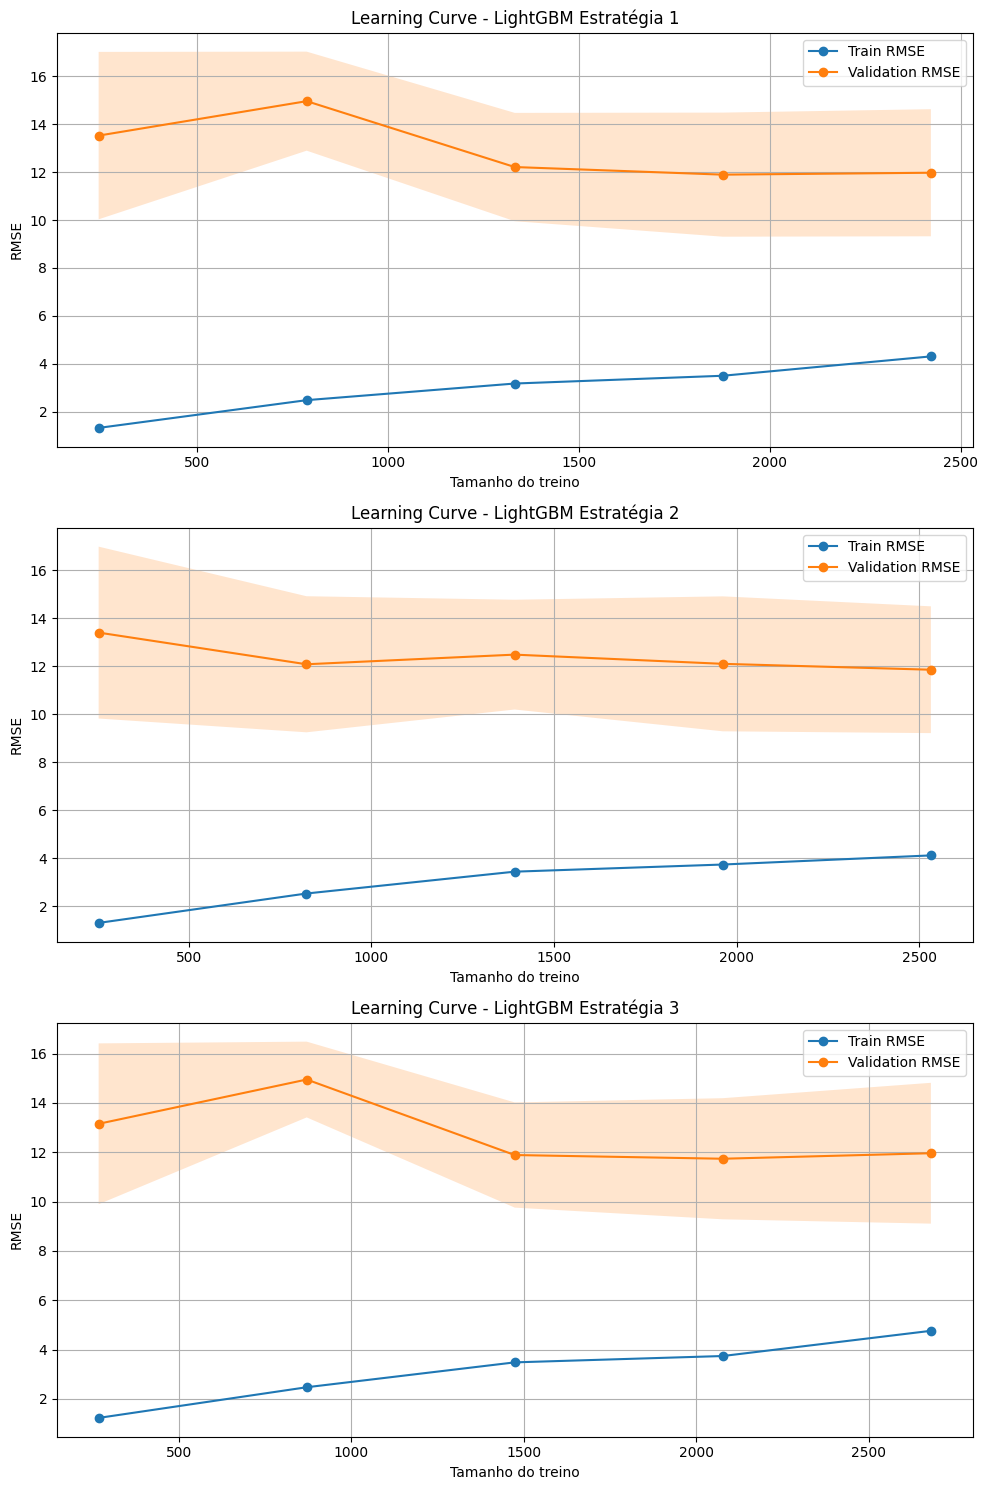

In [91]:
estrategias = {
    "Estratégia 1": (X_train_01, y_train_01),
    "Estratégia 2": (X_train_02, y_train_02),
    "Estratégia 3": (X_train_03, y_train_03),
}

plot_learning_curves_lgbm_estrateg(estrategias)

### As learning curves apresentam diferença relevante entre erro de treino e validação, sugerindo tendência de overfitting no modelo inicial.

## Gridsearch com hiperparâmetros diferentes e regularização

In [2]:
def grid_reg_lgbm(X_train, y_train, X_val, y_val, nome_estrategia):
    lgbm_base = LGBMRegressor(
        objective="regression",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        verbosity=-1
    )

    param_grid = {
        "n_estimators": [150, 300],
        "learning_rate": [0.03, 0.05],
        "max_depth": [3, 5],
        "num_leaves": [7, 15],
        "min_child_samples": [30, 50],
        "subsample": [0.8],
        "colsample_bytree": [0.8],
        "reg_lambda": [1, 5],
        "reg_alpha": [0, 0.1]
    }

    tscv = TimeSeriesSplit(n_splits=3)

    grid = GridSearchCV(
        estimator=lgbm_base,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)

    best_params = grid.best_params_

    model_final = LGBMRegressor(
        objective="regression",
        random_state=42,
        n_jobs=-1,
        verbose=0,
        verbosity=-1,
        **best_params
    )

    model_final.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[
            early_stopping(stopping_rounds=30),
            log_evaluation(period=0)
        ]
    )

    y_pred_val = model_final.predict(X_val)
    resultados = avaliar_modelo(y_val, y_pred_val)

    print(nome_estrategia)
    print("Melhores parâmetros:", best_params)
    print("Melhor RMSE CV:", -grid.best_score_)
    print("Melhor iteração:", model_final.best_iteration_)
    print("Resultados validação:", resultados)

    return grid, model_final, y_pred_val, resultados

In [11]:
grid_lgbm_01, lgbm_reg_01, y_pred_val_lgbm_reg_01, resultados_lgbm_reg_01 = grid_reg_lgbm(
    X_train_01, y_train_01,
    X_val_01, y_val_01,
    "Estratégia 1"
)

Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[150]	valid_0's rmse: 11.0903	valid_0's l2: 122.995
Estratégia 1
Melhores parâmetros: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_samples': 50, 'n_estimators': 150, 'num_leaves': 7, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.8}
Melhor RMSE CV: 10.383031850694463
Melhor iteração: 150
Resultados validação: {'MAE': 7.982446433069382, 'RMSE': 11.090309421913233, 'R2': 0.2975829940097392}


In [12]:
grid_lgbm_02, lgbm_reg_02, y_pred_val_lgbm_reg_02, resultados_lgbm_reg_02 = grid_reg_lgbm(
    X_train_02, y_train_02,
    X_val_02, y_val_02,
    "Estratégia 2"
)

Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[149]	valid_0's rmse: 11.0179	valid_0's l2: 121.393
Estratégia 2
Melhores parâmetros: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_samples': 30, 'n_estimators': 150, 'num_leaves': 15, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.8}
Melhor RMSE CV: 10.539730975384636
Melhor iteração: 149
Resultados validação: {'MAE': 7.933398178946784, 'RMSE': 11.017869336570799, 'R2': 0.30019730164890257}


In [13]:
grid_lgbm_03, lgbm_reg_03, y_pred_val_lgbm_reg_03, resultados_lgbm_reg_03 = grid_reg_lgbm(
    X_train_03, y_train_03,
    X_val_03, y_val_03,
    "Estratégia 3"
)

Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[150]	valid_0's rmse: 11.0903	valid_0's l2: 122.995
Estratégia 3
Melhores parâmetros: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_samples': 50, 'n_estimators': 150, 'num_leaves': 7, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.8}
Melhor RMSE CV: 10.383031850694463
Melhor iteração: 150
Resultados validação: {'MAE': 7.982446433069382, 'RMSE': 11.090309421913233, 'R2': 0.2975829940097392}


In [17]:
comparacao_reg = pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "Inicial", **resultados_gbm_01},
    {"estrategia": "Estratégia 1", "modelo": "Regularizado", **resultados_lgbm_reg_01},

    {"estrategia": "Estratégia 2", "modelo": "Inicial", **resultados_gbm_02},
    {"estrategia": "Estratégia 2", "modelo": "Regularizado", **resultados_lgbm_reg_02},

    {"estrategia": "Estratégia 3", "modelo": "Inicial", **resultados_gbm_03},
    {"estrategia": "Estratégia 3", "modelo": "Regularizado", **resultados_lgbm_reg_03},
])

comparacao_reg

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,Inicial,8.149680,11.426112,0.254402
1,Estratégia 1,Regularizado,7.982446,11.090309,0.297583
2,Estratégia 2,Inicial,8.067848,11.331423,0.259800
3,Estratégia 2,Regularizado,7.933398,11.017869,0.300197
4,Estratégia 3,Inicial,8.149680,11.426112,0.254402
5,Estratégia 3,Regularizado,7.982446,11.090309,0.297583


### teste na validação

In [19]:
y_pred_test_reg_03 = lgbm_reg_03.predict(X_test_03)

resultados_test_reg_03 = avaliar_modelo(y_test_03, y_pred_test_reg_03)

y_pred_test_reg_02 = lgbm_reg_02.predict(X_test_02)

resultados_test_reg_02 = avaliar_modelo(y_test_02, y_pred_test_reg_02)

y_pred_test_reg_01 = lgbm_reg_01.predict(X_test_01)

resultados_test_reg_01 = avaliar_modelo(y_test_01, y_pred_test_reg_01)

In [21]:
comparacao_test_reg = pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "LGBM Regularizado", **resultados_test_reg_01},
    {"estrategia": "Estratégia 2", "modelo": "LGBM Regularizado", **resultados_test_reg_02},
    {"estrategia": "Estratégia 3", "modelo": "LGBM Regularizado", **resultados_test_reg_03},
])

comparacao_test_reg 

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,LGBM Regularizado,7.836100,10.808724,0.280463
1,Estratégia 2,LGBM Regularizado,7.912577,10.956930,0.279421
2,Estratégia 3,LGBM Regularizado,7.836100,10.808724,0.280463


In [24]:
comparacao_test_models= pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "XGBoost Sem Regularização", **resultados_test_01},
    {"estrategia": "Estratégia 1", "modelo": "XGBoost Regularizado", **resultados_test_reg_01},
    {"estrategia": "Estratégia 2", "modelo": "XGBoost Sem Regularização", **resultados_test_02},
    {"estrategia": "Estratégia 2", "modelo": "XGBoost Regularizado", **resultados_test_reg_02},
    {"estrategia": "Estratégia 3", "modelo": "XGBoost Sem Regularização", **resultados_test_03},
    {"estrategia": "Estratégia 3", "modelo": "XGBoost Regularizado", **resultados_test_reg_03},
])

comparacao_test_models

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,XGBoost Sem Regularização,7.915592,11.051484,0.247779
1,Estratégia 1,XGBoost Regularizado,7.836100,10.808724,0.280463
2,Estratégia 2,XGBoost Sem Regularização,7.914312,11.085361,0.262430
3,Estratégia 2,XGBoost Regularizado,7.912577,10.956930,0.279421
4,Estratégia 3,XGBoost Sem Regularização,7.915592,11.051484,0.247779
5,Estratégia 3,XGBoost Regularizado,7.836100,10.808724,0.280463


### salvar os parametros para leaning curves

In [25]:
import json
import os

os.makedirs("../models", exist_ok=True)

best_params_lgbm = {
    "estrategia_01": grid_lgbm_01.best_params_,
    "estrategia_02": grid_lgbm_02.best_params_,
    "estrategia_03": grid_lgbm_03.best_params_,
}

with open("../models/best_params_lgbm_2016_2019.json", "w") as f:
    json.dump(best_params_lgbm, f, indent=4)